# Aprendizado Supervisionado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score,
)

In [2]:
from pathlib import Path
pasta_dados = Path("data")
pasta_dados.mkdir(exist_ok=True)

df_noticias = pd.read_csv(pasta_dados / "noticias.csv")
df_bow = pd.read_csv(pasta_dados/"bow.csv")
df_tfidf = pd.read_csv(pasta_dados/"tfidf.csv")

df_tfidf.head(2)

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,tfidf_votacao,tfidf_vulnerabilidade,tfidf_vulneraveis,tfidf_willian,tfidf_xadrez,tfidf_xxvii,tfidf_yago,tfidf_youtube,tfidf_zema,tfidf_zona
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_tfidf.columns.tolist()

['titulo',
 'subtitulo',
 'descricao',
 'temas',
 'data',
 'ano_mes',
 'ano',
 'mes',
 'hora',
 'turno',
 'n_temas',
 'tamanho_texto',
 'n_palavras_titulo',
 'n_relacionadas',
 'url',
 'tfidf_abastecimento',
 'tfidf_aberta',
 'tfidf_abertas',
 'tfidf_aberto',
 'tfidf_abertura',
 'tfidf_abrangendo',
 'tfidf_abre',
 'tfidf_abriu',
 'tfidf_acaba',
 'tfidf_acao',
 'tfidf_acende',
 'tfidf_acervo',
 'tfidf_acesso',
 'tfidf_achava',
 'tfidf_acidente',
 'tfidf_acirradas',
 'tfidf_aco',
 'tfidf_acoes',
 'tfidf_acompanhar',
 'tfidf_acompanhou',
 'tfidf_acontecera',
 'tfidf_acordo',
 'tfidf_administrado',
 'tfidf_administrativa',
 'tfidf_adolescentes',
 'tfidf_adorava',
 'tfidf_aeroporto',
 'tfidf_agencia',
 'tfidf_agora',
 'tfidf_agosto',
 'tfidf_agraciados',
 'tfidf_aguardada',
 'tfidf_aguiar',
 'tfidf_ai',
 'tfidf_ainda',
 'tfidf_ajuda',
 'tfidf_ajudando',
 'tfidf_alba',
 'tfidf_alcancar',
 'tfidf_alcancaram',
 'tfidf_alcancou',
 'tfidf_alegria',
 'tfidf_alem',
 'tfidf_alencar',
 'tfidf_alguma

## montando a matriz de features X

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [4]:
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]
X = df_tfidf[colunas_tfidf].values
print("X:", X.shape)

X: (323, 1313)


## Classificação - A notícia menciona Belo Horizonte?

Modelo construido visando identificar notícias que mencionam Belo Horizonte e, consequentemente,  avaliar se as notícias de esporte do site agência de Minas são centradas e monopolizadas na capital.

In [5]:
df_tfidf.columns

Index(['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno',
       ...
       'tfidf_votacao', 'tfidf_vulnerabilidade', 'tfidf_vulneraveis',
       'tfidf_willian', 'tfidf_xadrez', 'tfidf_xxvii', 'tfidf_yago',
       'tfidf_youtube', 'tfidf_zema', 'tfidf_zona'],
      dtype='object', length=1328)

In [6]:
texto = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_bh = texto.str.contains(r"Belo Horizonte|\bBH\b|capital", case=False, regex=True).astype(int).values

print("Distribuicao das classes:")
vc = pd.Series(y_bh).value_counts()
print(vc.rename({0: "nao menciona BH", 1: "menciona BH"}))
print(f"\n{vc[1] / len(y_bh):.1%} das noticias mencionam Belo Horizonte")

Distribuicao das classes:
nao menciona BH    303
menciona BH         20
Name: count, dtype: int64

6.2% das noticias mencionam Belo Horizonte


### separação em treino / validação / teste

In [7]:
X_tmp, X_teste_bh, y_tmp, y_teste_bh = train_test_split(
    X, y_bh, test_size=0.2, random_state=42, stratify=y_bh
)
X_treino_bh, X_calib_bh, y_treino_bh, y_calib_bh = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_bh.shape}")
print(f"calibracao: {X_calib_bh.shape}")
print(f"teste:      {X_teste_bh.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [8]:
modelo_bh = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_bh.fit(X_treino_bh, y_treino_bh)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### calibração

In [9]:
probs_calib_bh = modelo_bh.predict_proba(X_calib_bh)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_bh = []
for t in limiares:
    pred = (probs_calib_bh > t).astype(int)
    f1 = f1_score(y_calib_bh, pred, zero_division=0)
    resultados_bh.append((t, f1))

df_lim_bh = pd.DataFrame(resultados_bh, columns=["limiar", "f1_calib"])
melhor_limiar_bh = df_lim_bh.loc[df_lim_bh["f1_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_bh:.2f}")
df_lim_bh

Melhor limiar pela calibracao: 0.15


,limiar,f1_calib
0,0.10,0.666667
1,0.15,0.857143
2,0.20,0.857143
3,0.25,0.857143
4,0.30,0.857143
5,0.35,0.857143
6,0.40,0.666667
7,0.45,0.400000
8,0.50,0.400000
9,0.55,0.400000


### avaliando no teste

In [10]:
probs_teste_bh = modelo_bh.predict_proba(X_teste_bh)[:, 1]
pred_teste_bh = (probs_teste_bh > melhor_limiar_bh).astype(int)

acc  = accuracy_score(y_teste_bh, pred_teste_bh)
prec = precision_score(y_teste_bh, pred_teste_bh, zero_division=0)
rec  = recall_score(y_teste_bh, pred_teste_bh, zero_division=0)
f1   = f1_score(y_teste_bh, pred_teste_bh, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_bh, pred_teste_bh, target_names=["nao menciona BH", "menciona BH"]))

Acuracia: 1.000
Precisao: 1.000
Recall:   1.000
F1:       1.000

Relatorio completo:
                 precision    recall  f1-score   support

nao menciona BH       1.00      1.00      1.00        61
    menciona BH       1.00      1.00      1.00         4

       accuracy                           1.00        65
      macro avg       1.00      1.00      1.00        65
   weighted avg       1.00      1.00      1.00        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
                 nao menciona BH  menciona BH
nao menciona BH               61            0
menciona BH                    0            4


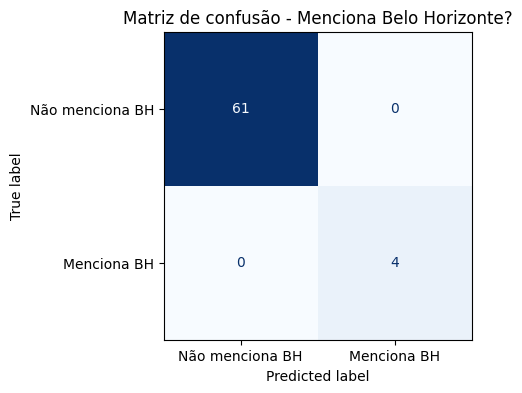

In [11]:
cm_bh = confusion_matrix(y_teste_bh, pred_teste_bh)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_bh, index=["nao menciona BH", "menciona BH"], columns=["nao menciona BH", "menciona BH"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_bh, display_labels=["Não menciona BH", "Menciona BH"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão - Menciona Belo Horizonte?")
plt.show()

## 2) Classificação - A notícia tem a tag Social?

A coluna `temas` contem as tags associadas a cada notícia. Esse modelo visa identificar as notícias de esporte que apresentam cunho social (inclusão, programas sociais, vulnerabilidade, entre outros.

In [12]:
y_social = df_tfidf["temas"].str.contains("Social", na=False).astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_social).value_counts().rename({0: "sem Social", 1: "com Social"}))

Distribuicao das classes:
com Social    176
sem Social    147
Name: count, dtype: int64


### separação em treino / validação / teste

In [13]:
X_tmp, X_teste_soc, y_tmp, y_teste_soc = train_test_split(
    X, y_social, test_size=0.2, random_state=42, stratify=y_social
)
X_treino_soc, X_calib_soc, y_treino_soc, y_calib_soc = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_soc.shape}")
print(f"calibracao: {X_calib_soc.shape}")
print(f"teste:      {X_teste_soc.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [14]:
from sklearn.linear_model import LogisticRegression

modelo_soc = LogisticRegression(max_iter=1000, random_state=42)
modelo_soc.fit(X_treino_soc, y_treino_soc)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### calibração

In [15]:
probs_calib_soc = modelo_soc.predict_proba(X_calib_soc)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_soc = []
for t in limiares:
    pred = (probs_calib_soc > t).astype(int)
    acc = accuracy_score(y_calib_soc, pred)
    resultados_soc.append((t, acc))

df_lim_soc = pd.DataFrame(resultados_soc, columns=["limiar", "acuracia_calib"])
melhor_limiar_soc = df_lim_soc.loc[df_lim_soc["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_soc:.2f}")
df_lim_soc

Melhor limiar pela calibracao: 0.55


,limiar,acuracia_calib
0,0.10,0.553846
1,0.15,0.553846
2,0.20,0.553846
3,0.25,0.553846
4,0.30,0.569231
5,0.35,0.569231
6,0.40,0.569231
7,0.45,0.569231
8,0.50,0.584615
9,0.55,0.646154


### avaliando no teste

In [16]:
probs_teste_soc = modelo_soc.predict_proba(X_teste_soc)[:, 1]
pred_teste_soc = (probs_teste_soc > melhor_limiar_soc).astype(int)

acc  = accuracy_score(y_teste_soc, pred_teste_soc)
prec = precision_score(y_teste_soc, pred_teste_soc, zero_division=0)
rec  = recall_score(y_teste_soc, pred_teste_soc, zero_division=0)
f1   = f1_score(y_teste_soc, pred_teste_soc, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_soc, pred_teste_soc, target_names=["sem Social", "com Social"]))

Acuracia: 0.631
Precisao: 0.657
Recall:   0.657
F1:       0.657

Relatorio completo:
              precision    recall  f1-score   support

  sem Social       0.60      0.60      0.60        30
  com Social       0.66      0.66      0.66        35

    accuracy                           0.63        65
   macro avg       0.63      0.63      0.63        65
weighted avg       0.63      0.63      0.63        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
            sem Social  com Social
sem Social          18          12
com Social          12          23


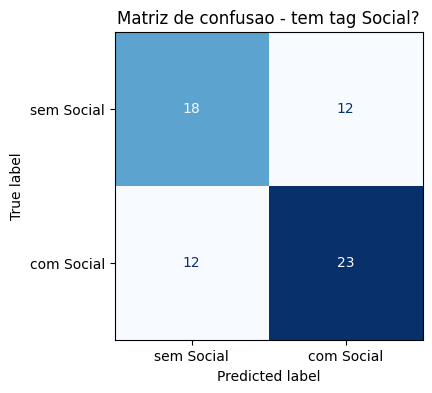

In [17]:
cm_soc = confusion_matrix(y_teste_soc, pred_teste_soc)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_soc, index=["sem Social", "com Social"], columns=["sem Social", "com Social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_soc, display_labels=["sem Social", "com Social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - tem tag Social?")
plt.show()

## 3) Regressão - Prever o numero de temas da notícia.

O vocabulário do texto consegue prever o quão ampla é a cobertura editoral da notícia? Ou seja, a partir do texto da notícia, conseguimos prever a dimensão de temas que ela engloba?

In [18]:
y_reg = df_tfidf["n_temas"].values

print("Estatisticas do alvo:")
print(pd.Series(y_reg).describe())

Estatisticas do alvo:
count    323.000000
mean       2.346749
std        0.970311
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
dtype: float64


### separação em treino / validação / teste

In [19]:
X_tmp, X_teste_r, y_tmp, y_teste_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42
)

print(f"treino:     {X_treino_r.shape}")
print(f"calibracao: {X_calib_r.shape}")
print(f"teste:      {X_teste_r.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo e escolhendo o número de árvores.

In [20]:
n_estimators_list = [10, 50, 100, 200, 400]
resultados_reg = []
modelos_reg = {}

for n in n_estimators_list:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    pred_calib = modelo.predict(X_calib_r)
    mae = mean_absolute_error(y_calib_r, pred_calib)
    resultados_reg.append((n, mae))
    modelos_reg[n] = modelo

df_reg = pd.DataFrame(resultados_reg, columns=["n_estimators", "MAE_calib"])
melhor_n = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n}")
df_reg

Melhor n_estimators pela calibracao: 400


,n_estimators,MAE_calib
0,10,0.661795
1,50,0.627056
2,100,0.623136
3,200,0.619260
4,400,0.617955


### avaliando no teste

In [21]:
modelo_final = modelos_reg[melhor_n]
pred_teste_r = modelo_final.predict(X_teste_r)

print(f"MAE no teste: {mean_absolute_error(y_teste_r, pred_teste_r):.2f}")
print(f"R\u00b2  no teste: {r2_score(y_teste_r, pred_teste_r):.3f}")

df_comp = pd.DataFrame({
    "real": y_teste_r,
    "previsto": pred_teste_r.round(1),
}).head(10)
df_comp

MAE no teste: 0.61
R²  no teste: 0.191


,real,previsto
0,2,2.2
1,2,2.2
2,2,1.8
3,1,2.2
4,2,2.1
5,2,2.1
6,2,2.1
7,2,2.3
8,2,2.0
9,2,2.0


# teste

In [22]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_svm.fit(X_treino_soc, y_treino_soc)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [23]:
probs_calib_svm = modelo_svm.predict_proba(X_calib_soc)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_svm = []
for t in limiares:
    pred = (probs_calib_svm > t).astype(int)
    acc = accuracy_score(y_calib_soc, pred)
    resultados_svm.append((t, acc))

df_lim_svm = pd.DataFrame(resultados_svm, columns=["limiar", "acuracia_calib"])
melhor_limiar_svm = df_lim_svm.loc[df_lim_svm["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_svm:.2f}")
df_lim_svm

Melhor limiar pela calibracao: 0.55


,limiar,acuracia_calib
0,0.10,0.553846
1,0.15,0.553846
2,0.20,0.569231
3,0.25,0.569231
4,0.30,0.569231
5,0.35,0.569231
6,0.40,0.600000
7,0.45,0.584615
8,0.50,0.615385
9,0.55,0.661538


In [24]:
probs_teste_svm = modelo_svm.predict_proba(X_teste_soc)[:, 1]
pred_teste_svm = (probs_teste_svm > melhor_limiar_svm).astype(int)

acc  = accuracy_score(y_teste_soc, pred_teste_svm)
prec = precision_score(y_teste_soc, pred_teste_svm, zero_division=0)
rec  = recall_score(y_teste_soc, pred_teste_svm, zero_division=0)
f1   = f1_score(y_teste_soc, pred_teste_svm, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_soc, pred_teste_svm, target_names=["sem Social", "com Social"]))

Acuracia: 0.662
Precisao: 0.710
Recall:   0.629
F1:       0.667

Relatorio completo:
              precision    recall  f1-score   support

  sem Social       0.62      0.70      0.66        30
  com Social       0.71      0.63      0.67        35

    accuracy                           0.66        65
   macro avg       0.66      0.66      0.66        65
weighted avg       0.67      0.66      0.66        65



Matriz de confusao (linhas=real, colunas=previsto):
            sem Social  com Social
sem Social          21           9
com Social          13          22


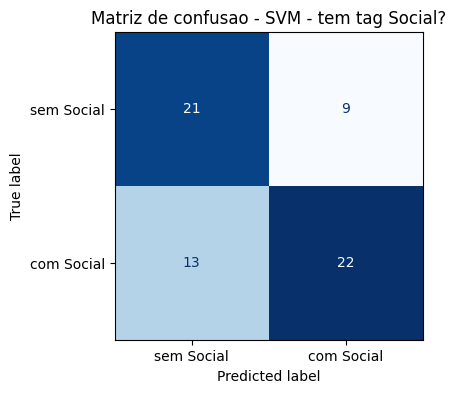

In [25]:
cm_svm = confusion_matrix(y_teste_soc, pred_teste_svm)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_svm, index=["sem Social", "com Social"], columns=["sem Social", "com Social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_svm, display_labels=["sem Social", "com Social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - SVM - tem tag Social?")
plt.show()